 # 编程实践题2：空间权重矩阵构建与空间回归模型

 适配环境：Python 3.13 + spreg 1.9 + geopandas 1.1 + numpy 2.4

 分析流程：
 1. 数据加载与预处理（筛选2021年、直辖市映射、合并）
 2. 空间权重矩阵构建（Queen + KNN(4) + KNN(8)）与可视化
 3. OLS 基准模型（statsmodels）
 4. 空间回归模型（spreg 1.9 API）：SAR、SEM、SDM
 5. LM 检验（spreg OLS 的 spat_diag）
 6. 模型比较（R²、AIC、Log-Likelihood）
 7. 残差 Moran's I 对比

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import geopandas as gpd
from libpysal.weights import Queen, KNN
from esda.moran import Moran
import statsmodels.api as sm

# spreg 1.9 API
from spreg import OLS as SpregOLS, ML_Lag, ML_Error

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'PingFang SC', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("编程实践题2：空间权重矩阵构建与空间回归模型")
print("案例：中国地级市经济发展水平的空间回归分析")
print("=" * 60)

编程实践题2：空间权重矩阵构建与空间回归模型
案例：中国地级市经济发展水平的空间回归分析


In [ ]:
# 第一步：数据加载与合并
# ---------------------------------------------------------------
import os
data_dir = os.path.join('..', 'data', 'china')

shp_path = os.path.join(data_dir, 'city.shp')
gdf = gpd.read_file(shp_path, encoding='utf-8')
print(f"\n[1] Shapefile 加载完成: {len(gdf)} 个空间单元")

csv_path = os.path.join(data_dir, '地级市数据.csv')
df_attr = pd.read_csv(csv_path, encoding='utf-8')
print(f"[2] CSV 加载完成: {df_attr.shape}, 年份 {df_attr['year'].min()}~{df_attr['year'].max()}")

ANALYSIS_YEAR = 2021
df_year = df_attr[df_attr['year'] == ANALYSIS_YEAR].copy()
df_year['adcode'] = df_year['行政区划代码'].astype(str).str.zfill(6)
MUNICIPALITY_MAP = {
    '110000': '110100', '120000': '120100',
    '310000': '310100', '500000': '500100',
}
df_year['adcode_mapped'] = df_year['adcode'].map(lambda c: MUNICIPALITY_MAP.get(c, c))

gdf_merged = gdf.merge(df_year, left_on='ct_adcode', right_on='adcode_mapped',
                        how='left', suffixes=('', '_csv'))
matched = gdf_merged['year'].notna().sum()
print(f"[3] 合并完成: {len(gdf_merged)} 个空间单元, 成功匹配 {matched} 个")


[1] Shapefile 加载完成: 372 个空间单元
[2] CSV 加载完成: (5420, 31), 年份 2003~2021
[3] 合并完成: 372 个空间单元, 成功匹配 287 个


In [ ]:
# 第二步：变量选择
# ---------------------------------------------------------------
Y_VAR = '经济发展水平'
X_VARS = ['城镇化水平', '金融发展程度', '对外开放水平', '基础设施',
           '人力资本水平', '产业结构高级化', '环境规制']

gdf_valid = gdf_merged.dropna(subset=[Y_VAR] + X_VARS).copy()
n_valid = len(gdf_valid)
print(f"\n[4] 有效样本: {n_valid} 个城市")

y = gdf_valid[Y_VAR].values.astype(float)
X = gdf_valid[X_VARS].values.astype(float)
# spreg 需要 X 包含常数项
X_const = np.column_stack([np.ones(n_valid), X])
x_names = ['常数项'] + X_VARS
print(f"    因变量: {Y_VAR}")
print(f"    自变量 ({len(X_VARS)}): {', '.join(X_VARS)}")


[4] 有效样本: 279 个城市
    因变量: 经济发展水平
    自变量 (7): 城镇化水平, 金融发展程度, 对外开放水平, 基础设施, 人力资本水平, 产业结构高级化, 环境规制



第三步：空间权重矩阵构建
('WARNING: ', 219, ' is an island (no neighbors)')
('WARNING: ', 220, ' is an island (no neighbors)')
('WARNING: ', 274, ' is an island (no neighbors)')
('WARNING: ', 278, ' is an island (no neighbors)')

  [1] Queen: 279 单元, 平均邻居 4.9, 孤岛 4
  [2] KNN(4): 279 单元
  [3] KNN(8): 279 单元

  主权重: Queen


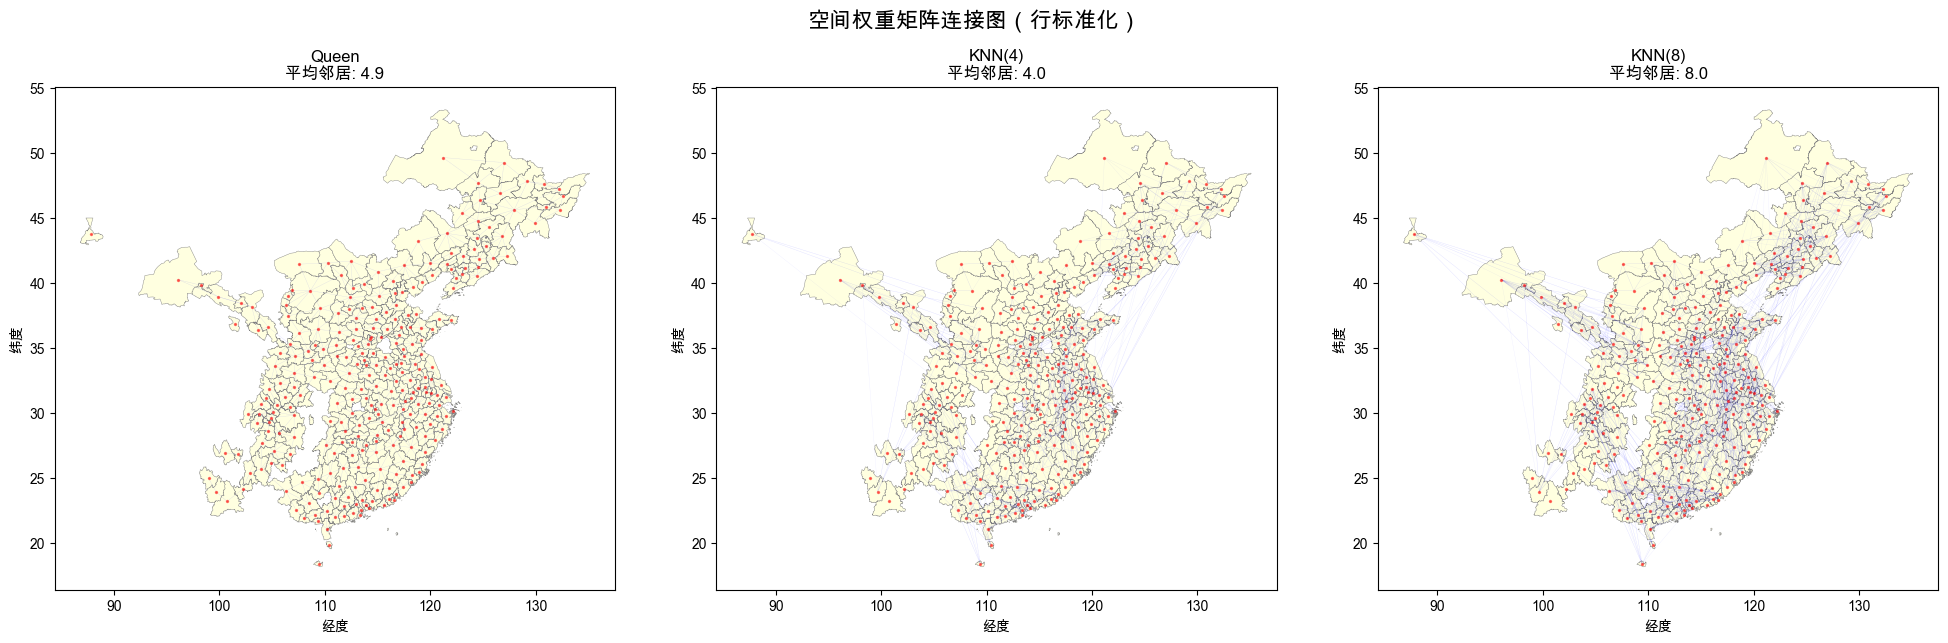

  → output_01_weight_connections.png


In [ ]:
# 第三步：空间权重矩阵构建
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("第三步：空间权重矩阵构建")
print("=" * 60)

weight_schemes = {}

# Queen
queen_ok = False
try:
    w_queen = Queen.from_dataframe(gdf_valid)
    w_queen.transform = 'r'
    queen_ok = True
    n_isolates = len(w_queen.islands) if hasattr(w_queen, 'islands') else 0
    avg_n = np.mean([len(v) for v in w_queen.neighbors.values()])
    print(f"\n  [1] Queen: {w_queen.n} 单元, 平均邻居 {avg_n:.1f}, 孤岛 {n_isolates}")
    weight_schemes['Queen'] = w_queen
except Exception as e:
    print(f"\n  [1] Queen 构建失败: {e}")

# KNN(4)
w_knn4 = KNN.from_dataframe(gdf_valid, k=4)
w_knn4.transform = 'r'
weight_schemes['KNN(4)'] = w_knn4
print(f"  [2] KNN(4): {w_knn4.n} 单元")

# KNN(8)
w_knn8 = KNN.from_dataframe(gdf_valid, k=8)
w_knn8.transform = 'r'
weight_schemes['KNN(8)'] = w_knn8
print(f"  [3] KNN(8): {w_knn8.n} 单元")

# 选择主权重
primary_name = 'Queen' if queen_ok else 'KNN(4)'
w = weight_schemes[primary_name]
print(f"\n  主权重: {primary_name}")

# 权重连接可视化
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('空间权重矩阵连接图（行标准化）', fontsize=16, y=1.02)

centroids = gdf_valid.geometry.centroid
coords = list(zip(centroids.x, centroids.y))
coord_map = dict(enumerate(coords))

for idx, (name, wi) in enumerate(weight_schemes.items()):
    ax = axes[idx]
    gdf_valid.plot(ax=ax, facecolor='lightyellow', edgecolor='gray', linewidths=0.3)
    for i, neighbors in wi.neighbors.items():
        ci = coord_map.get(i)
        if ci is None:
            continue
        for j in neighbors:
            cj = coord_map.get(j)
            if cj is None:
                continue
            ax.plot([ci[0], cj[0]], [ci[1], cj[1]], 'b-', alpha=0.06, linewidth=0.3)
    cx = [c[0] for c in coords]
    cy = [c[1] for c in coords]
    ax.scatter(cx, cy, s=2, c='red', zorder=5, alpha=0.5)
    avg_n = np.mean([len(wi.neighbors[i]) for i in wi.id_order])
    ax.set_title(f'{name}\n平均邻居: {avg_n:.1f}', fontsize=12)
    ax.set_xlabel('经度')
    ax.set_ylabel('纬度')

plt.tight_layout()
plt.savefig('output_01_weight_connections.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → output_01_weight_connections.png")


第四步：OLS 基准模型

  R² = 0.6214, Adj-R² = 0.6116
  AIC = 89.56, Log-Lik = -36.78
  F = 63.53, p = 1.44e-53

  const          =    9.9163  p=0.0000 ***
  城镇化水平          =    2.1864  p=0.0000 ***
  金融发展程度         =   -0.1503  p=0.0000 ***
  对外开放水平         =   -0.0148  p=0.9832 
  基础设施           =    0.0000  p=0.3601 
  人力资本水平         =    5.8915  p=0.0000 ***
  产业结构高级化        =   -0.1153  p=0.0002 ***
  环境规制           =    0.0032  p=0.0000 ***


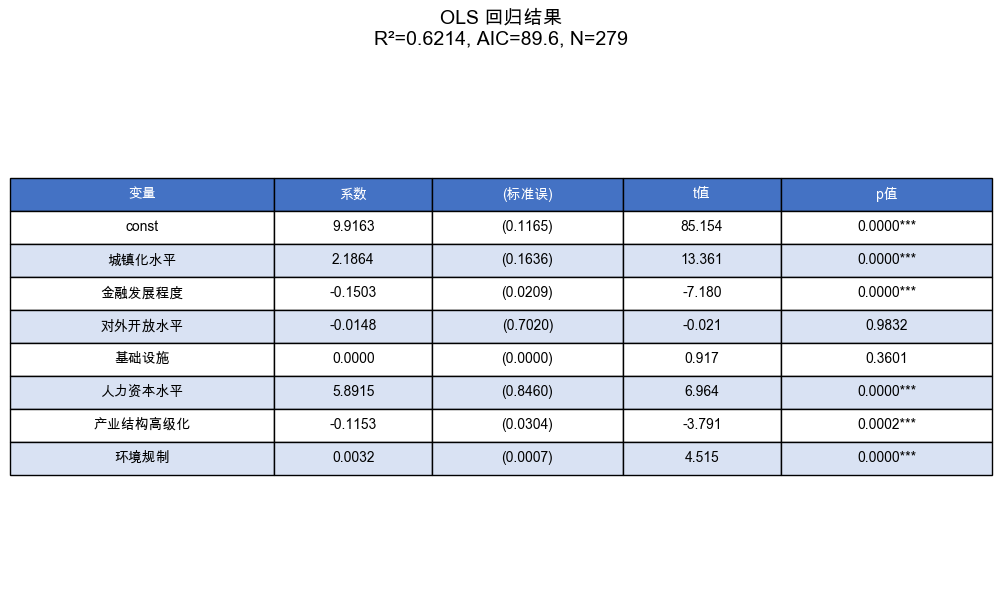

  → output_02_ols_summary.png


In [ ]:
# 第四步：OLS 基准模型（statsmodels）
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("第四步：OLS 基准模型")
print("=" * 60)

X_sm = sm.add_constant(gdf_valid[X_VARS])
ols_sm = sm.OLS(y, X_sm).fit()

print(f"\n  R² = {ols_sm.rsquared:.4f}, Adj-R² = {ols_sm.rsquared_adj:.4f}")
print(f"  AIC = {ols_sm.aic:.2f}, Log-Lik = {ols_sm.llf:.2f}")
print(f"  F = {ols_sm.fvalue:.2f}, p = {ols_sm.f_pvalue:.2e}\n")

for name in X_sm.columns:
    c = ols_sm.params[name]
    p = ols_sm.pvalues[name]
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f"  {name:<14} = {c:>9.4f}  p={p:.4f} {sig}")

# OLS 结果表格图
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
table_data = []
for name in X_sm.columns:
    c = ols_sm.params[name]
    se = ols_sm.bse[name]
    t = ols_sm.tvalues[name]
    p = ols_sm.pvalues[name]
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    table_data.append([name, f'{c:.4f}', f'({se:.4f})', f'{t:.3f}', f'{p:.4f}{sig}'])

tbl = ax.table(cellText=table_data,
               colLabels=['变量', '系数', '(标准误)', 't值', 'p值'],
               loc='center', cellLoc='center',
               colWidths=[0.25, 0.15, 0.18, 0.15, 0.2])
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.8)
for j in range(5):
    tbl[(0, j)].set_facecolor('#4472C4')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
for i in range(1, len(table_data) + 1):
    for j in range(5):
        if i % 2 == 0:
            tbl[(i, j)].set_facecolor('#D9E2F3')
ax.set_title(f'OLS 回归结果\nR²={ols_sm.rsquared:.4f}, AIC={ols_sm.aic:.1f}, N={n_valid}',
             fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('output_02_ols_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → output_02_ols_summary.png")


第五步：LM 检验（空间依赖性诊断）

检验                            统计量           p值       显著
───────────────────────────────────────────────────────
  LM-Lag                   5.9492     0.014724        *
  LM-Error                88.7023     0.000000      ***
  Robust LM-Lag            1.0426     0.307212     n.s.
  Robust LM-Error         83.7958     0.000000      ***

  → 推荐: SEM (Robust LM-Error 显著, Robust LM-Lag 不显著)


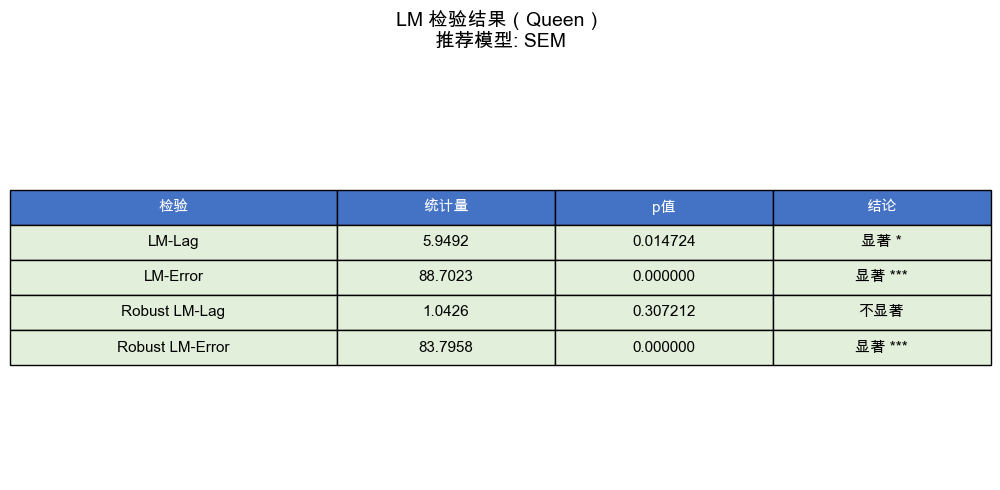

  → output_03_lm_tests.png


In [ ]:
# 第五步：LM 检验
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("第五步：LM 检验（空间依赖性诊断）")
print("=" * 60)

ols_spreg = SpregOLS(y, X_const, w=w, name_y=Y_VAR, name_x=x_names, spat_diag=True)

# spreg 1.9: LM 统计量直接在对象上，格式为 (stat, p) 元组
lm_lag = ols_spreg.lm_lag        # (stat, p)
lm_error = ols_spreg.lm_error
rlm_lag = ols_spreg.rlm_lag
rlm_error = ols_spreg.rlm_error

print(f"\n{'检验':<22} {'统计量':>10} {'p值':>12} {'显著':>8}")
print(f"{'─' * 55}")
for label, val in [('LM-Lag', lm_lag), ('LM-Error', lm_error),
                    ('Robust LM-Lag', rlm_lag), ('Robust LM-Error', rlm_error)]:
    stat, p = val[0], val[1]
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'n.s.'))
    print(f"  {label:<20} {stat:>10.4f} {p:>12.6f} {sig:>8}")

# 判断逻辑
lag_sig = lm_lag[1] < 0.05
err_sig = lm_error[1] < 0.05
rlag_sig = rlm_lag[1] < 0.05
rerr_sig = rlm_error[1] < 0.05

if lag_sig and err_sig:
    if rlag_sig and not rerr_sig:
        recommendation = "SAR"
        reason = "Robust LM-Lag 显著, Robust LM-Error 不显著"
    elif rerr_sig and not rlag_sig:
        recommendation = "SEM"
        reason = "Robust LM-Error 显著, Robust LM-Lag 不显著"
    else:
        recommendation = "SDM"
        reason = "LM-Lag 和 LM-Error 及 Robust 均显著"
elif lag_sig:
    recommendation = "SAR"
    reason = "仅 LM-Lag 显著"
elif err_sig:
    recommendation = "SEM"
    reason = "仅 LM-Error 显著"
else:
    recommendation = "OLS"
    reason = "LM 检验均不显著"

print(f"\n  → 推荐: {recommendation} ({reason})")

# LM 检验可视化
fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')
lm_table = []
for label, val in [('LM-Lag', lm_lag), ('LM-Error', lm_error),
                    ('Robust LM-Lag', rlm_lag), ('Robust LM-Error', rlm_error)]:
    stat, p = val[0], val[1]
    sig = '显著 ***' if p < 0.001 else ('显著 **' if p < 0.01 else ('显著 *' if p < 0.05 else '不显著'))
    lm_table.append([label, f'{stat:.4f}', f'{p:.6f}', sig])

lt = ax.table(cellText=lm_table,
              colLabels=['检验', '统计量', 'p值', '结论'],
              loc='center', cellLoc='center', colWidths=[0.3, 0.2, 0.2, 0.2])
lt.auto_set_font_size(False)
lt.set_fontsize(11)
lt.scale(1.3, 2.0)
for j in range(4):
    lt[(0, j)].set_facecolor('#4472C4')
    lt[(0, j)].set_text_props(color='white', fontweight='bold')
for i in range(1, 5):
    if '显著' in lm_table[i - 1][3]:
        for j in range(4):
            lt[(i, j)].set_facecolor('#E2EFDA')
ax.set_title(f'LM 检验结果（{primary_name}）\n推荐模型: {recommendation}',
             fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('output_03_lm_tests.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → output_03_lm_tests.png")

In [ ]:
# 第六步：空间回归模型估计
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("第六步：空间回归模型估计")
print("=" * 60)

models = {}

# OLS 基准
models['OLS'] = {
    'r2': ols_sm.rsquared,
    'aic': ols_spreg.aic,
    'loglik': ols_spreg.logll,
    'resid': ols_spreg.u,
}

# --- SAR (ML_Lag) ---
print("\n--- SAR 空间滞后模型 ---")
try:
    sar = ML_Lag(y, X_const, w=w, name_y=Y_VAR, name_x=x_names)
    rho = float(sar.betas.flatten()[-1])
    rho_z, rho_p = sar.z_stat[-1]
    models['SAR'] = {
        'r2': float(sar.pr2),
        'aic': float(sar.aic),
        'loglik': float(sar.logll),
        'resid': sar.u,
        'rho': rho,
        'rho_z': float(rho_z),
        'rho_p': float(rho_p),
    }
    sig = '***' if rho_p < 0.001 else ('**' if rho_p < 0.01 else ('*' if rho_p < 0.05 else ''))
    print(f"  ρ = {rho:.6f}, z = {rho_z:.4f}, p = {rho_p:.6f} {sig}")
    print(f"  伪R² = {sar.pr2:.4f}, AIC = {sar.aic:.2f}")
    print("  SAR 估计成功 ✓")
except Exception as e:
    print(f"  SAR 估计失败: {e}")

# --- SEM (ML_Error) ---
print("\n--- SEM 空间误差模型 ---")
try:
    sem = ML_Error(y, X_const, w=w, name_y=Y_VAR, name_x=x_names)
    lam = float(sem.betas.flatten()[-1])
    lam_z, lam_p = sem.z_stat[-1]
    models['SEM'] = {
        'r2': float(sem.pr2),
        'aic': float(sem.aic),
        'loglik': float(sem.logll),
        'resid': sem.u,
        'lam': lam,
        'lam_z': float(lam_z),
        'lam_p': float(lam_p),
    }
    sig = '***' if lam_p < 0.001 else ('**' if lam_p < 0.01 else ('*' if lam_p < 0.05 else ''))
    print(f"  λ = {lam:.6f}, z = {lam_z:.4f}, p = {lam_p:.6f} {sig}")
    print(f"  伪R² = {sem.pr2:.4f}, AIC = {sem.aic:.2f}")
    print("  SEM 估计成功 ✓")
except Exception as e:
    print(f"  SEM 估计失败: {e}")

# --- SDM (ML_Lag + slx_lags=1) ---
print("\n--- SDM 空间杜宾模型 ---")
try:
    sdm = ML_Lag(y, X_const, w=w, slx_lags=1, name_y=Y_VAR, name_x=x_names)
    rho_sdm = float(sdm.betas.flatten()[-1])
    rho_z_sdm, rho_p_sdm = sdm.z_stat[-1]
    models['SDM'] = {
        'r2': float(sdm.pr2),
        'aic': float(sdm.aic),
        'loglik': float(sdm.logll),
        'resid': sdm.u,
        'rho': rho_sdm,
        'rho_z': float(rho_z_sdm),
        'rho_p': float(rho_p_sdm),
    }
    sig = '***' if rho_p_sdm < 0.001 else ('**' if rho_p_sdm < 0.01 else ('*' if rho_p_sdm < 0.05 else ''))
    print(f"  ρ = {rho_sdm:.6f}, z = {rho_z_sdm:.4f}, p = {rho_p_sdm:.6f} {sig}")
    print(f"  伪R² = {sdm.pr2:.4f}, AIC = {sdm.aic:.2f}")
    print("  SDM 估计成功 ✓")
except Exception as e:
    print(f"  SDM 估计失败: {e}")


第六步：空间回归模型估计

--- SAR 空间滞后模型 ---
ML_Lag
  ρ = 0.032890, z = 2.4517, p = 0.014219 *
  伪R² = 0.6295, AIC = 85.59
  SAR 估计成功 ✓

--- SEM 空间误差模型 ---
ML_Error
  λ = 0.626221, z = 11.4973, p = 0.000000 ***
  伪R² = 0.6003, AIC = 3.83
  SEM 估计成功 ✓

--- SDM 空间杜宾模型 ---
ML_Lag
  ρ = 0.030896, z = 1.2876, p = 0.197894 
  伪R² = 0.6884, AIC = 51.30
  SDM 估计成功 ✓
  ρ = 0.030896, z = 1.2876, p = 0.197894 
  伪R² = 0.6884, AIC = 51.30
  SDM 估计成功 ✓



第七步：模型比较

  模型           R²/伪R²          AIC       LogLik                 空间参数
  ─────────────────────────────────────────────────────────────────
  OLS          0.6214        89.56       -36.78                 (基准)
  SAR          0.6295        85.59       -33.79           ρ = 0.0329
  SEM          0.6003         3.83         6.08           λ = 0.6262
  SDM          0.6884        51.30        -9.65           ρ = 0.0309

  → 最优（AIC最小）: SEM (AIC = 3.83)


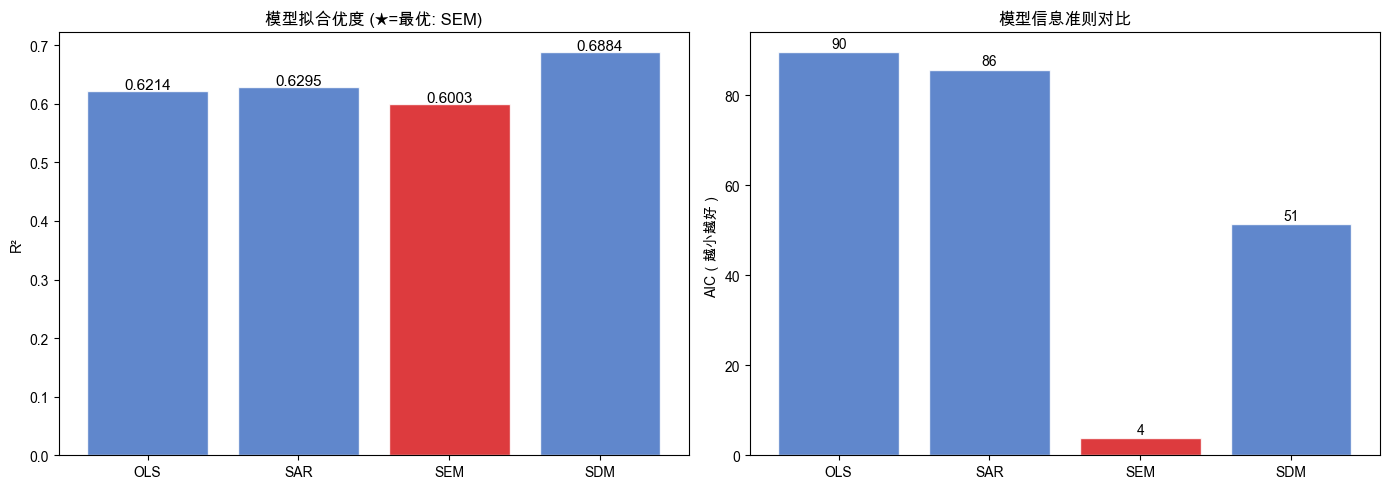

  → output_04_model_comparison.png


In [ ]:
# 第七步：模型比较
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("第七步：模型比较")
print("=" * 60)

print(f"\n  {'模型':<8} {'R²/伪R²':>10} {'AIC':>12} {'LogLik':>12} {'空间参数':>20}")
print(f"  {'─' * 65}")
for mname, m in models.items():
    r2_str = f"{m['r2']:.4f}"
    sp_str = ''
    if 'rho' in m and 'lam' in m:
        sp_str = f"ρ={m['rho']:.4f}, λ={m['lam']:.4f}"
    elif 'rho' in m:
        sp_str = f"ρ = {m['rho']:.4f}"
    elif 'lam' in m:
        sp_str = f"λ = {m['lam']:.4f}"
    else:
        sp_str = '(基准)'
    print(f"  {mname:<8} {r2_str:>10} {m['aic']:>12.2f} {m['loglik']:>12.2f} {sp_str:>20}")

# 最优模型
best = min(models, key=lambda k: models[k]['aic'])
print(f"\n  → 最优（AIC最小）: {best} (AIC = {models[best]['aic']:.2f})")

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
names = list(models.keys())
r2s = [models[n]['r2'] for n in names]
aics = [models[n]['aic'] for n in names]
colors = ['#d7191c' if n == best else '#4472C4' for n in names]

bars = axes[0].bar(names, r2s, color=colors, edgecolor='white', alpha=0.85)
for b, v in zip(bars, r2s):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.003,
                 f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
axes[0].set_ylabel('R²')
axes[0].set_title(f'模型拟合优度 (★=最优: {best})')

bars2 = axes[1].bar(names, aics, color=colors, edgecolor='white', alpha=0.85)
for b, v in zip(bars2, aics):
    axes[1].text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
                 f'{v:.0f}', ha='center', fontsize=10)
axes[1].set_ylabel('AIC（越小越好）')
axes[1].set_title('模型信息准则对比')

plt.tight_layout()
plt.savefig('output_04_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → output_04_model_comparison.png")


第八步：残差 Moran's I 检验

  模型          Moran I         Z值           p值        空间自相关
  ───────────────────────────────────────────────────────
  OLS          0.3830     9.5887     0.001000        显著 ⚠️
  SAR          0.3664     9.1763     0.001000        显著 ⚠️
  SEM          0.4956    12.3810     0.001000        显著 ⚠️
  SDM          0.2609     6.5607     0.001000        显著 ⚠️


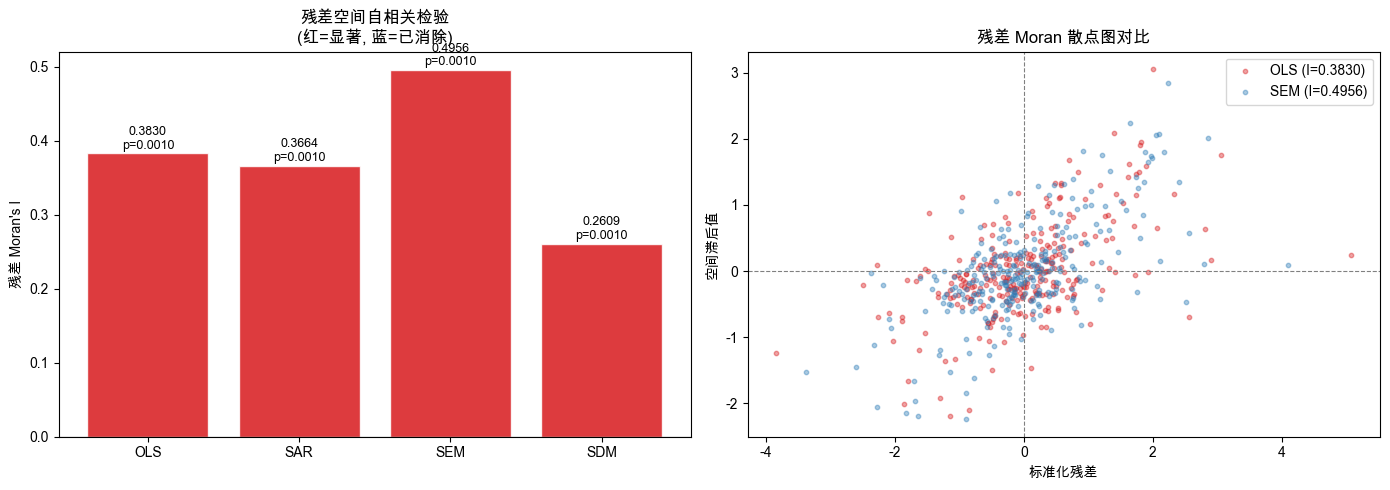

  → output_05_residual_moran.png


In [ ]:
# 第八步：残差 Moran's I 对比
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("第八步：残差 Moran's I 检验")
print("=" * 60)

print(f"\n  {'模型':<8} {'Moran I':>10} {'Z值':>10} {'p值':>12} {'空间自相关':>12}")
print(f"  {'─' * 55}")

moran_data = []
for mname, m in models.items():
    resid = m['resid']
    mi = Moran(resid, w, permutations=999)
    status = '显著 ⚠️' if mi.p_sim < 0.05 else '已消除 ✓'
    print(f"  {mname:<8} {mi.I:>10.4f} {mi.z_norm:>10.4f} {mi.p_sim:>12.6f} {status:>12}")
    moran_data.append((mname, mi.I, mi.z_norm, mi.p_sim, status))

# 残差 Moran's I 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) 柱状图
mnames = [d[0] for d in moran_data]
mvals = [d[1] for d in moran_data]
mpvals = [d[3] for d in moran_data]
bar_colors = ['#d7191c' if p < 0.05 else '#2c7bb6' for p in mpvals]
bars = axes[0].bar(mnames, mvals, color=bar_colors, edgecolor='white', alpha=0.85)
for b, v, p in zip(bars, mvals, mpvals):
    axes[0].text(b.get_x() + b.get_width() / 2, b.get_height() + 0.002,
                 f'{v:.4f}\np={p:.4f}', ha='center', va='bottom', fontsize=9)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel("残差 Moran's I")
axes[0].set_title("残差空间自相关检验\n(红=显著, 蓝=已消除)")

# (b) Moran 散点图对比
ax = axes[1]
ols_r = models['OLS']['resid']
y_std = (ols_r - ols_r.mean()) / ols_r.std()
lag_ols = w.sparse.dot(y_std)
m_ols = Moran(ols_r, w, permutations=999)
ax.scatter(y_std, lag_ols, s=10, alpha=0.4, c='#d7191c', label=f'OLS (I={m_ols.I:.4f})')

if best != 'OLS' and best in models:
    best_r = models[best]['resid']
    y_std2 = (best_r - best_r.mean()) / best_r.std()
    lag_best = w.sparse.dot(y_std2)
    m_best = Moran(best_r, w, permutations=999)
    ax.scatter(y_std2, lag_best, s=10, alpha=0.4, c='#2c7bb6', label=f'{best} (I={m_best.I:.4f})')

ax.axhline(0, color='gray', ls='--', lw=0.8)
ax.axvline(0, color='gray', ls='--', lw=0.8)
ax.set_xlabel('标准化残差')
ax.set_ylabel('空间滞后值')
ax.set_title(f'残差 Moran 散点图对比')
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('output_05_residual_moran.png', dpi=150, bbox_inches='tight')
plt.show()
print("  → output_05_residual_moran.png")


第九步：SDM 系数解读
ML_Lag

  变量                       系数         z值         p值     显著
  ───────────────────────────────────────────────────────
  常数项                  9.5501    44.6548     0.0000    ***
  城镇化水平                2.3295    12.9383     0.0000    ***
  金融发展程度              -0.1518    -6.6959     0.0000    ***
  对外开放水平               0.2399     0.3722     0.7097       
  基础设施                 0.0000     0.8025     0.4223       
  人力资本水平               5.0194     5.6677     0.0000    ***
  产业结构高级化             -0.0321    -1.0230     0.3063       
  环境规制                 0.0016     2.1475     0.0318      *

  空间滞后解释变量 (WX):
  W·城镇化水平            -0.1629    -0.5642     0.5726       
  W·金融发展程度            0.0425     1.1899     0.2341       
  W·对外开放水平           -2.7217    -2.5357     0.0112      *
  W·基础设施              0.0001     1.1564     0.2475       
  W·人力资本水平            3.2846     1.9615     0.0498      *
  W·产业结构高级化          -0.2819    -5.4073     0.0000    ***
  W·环境规制              0

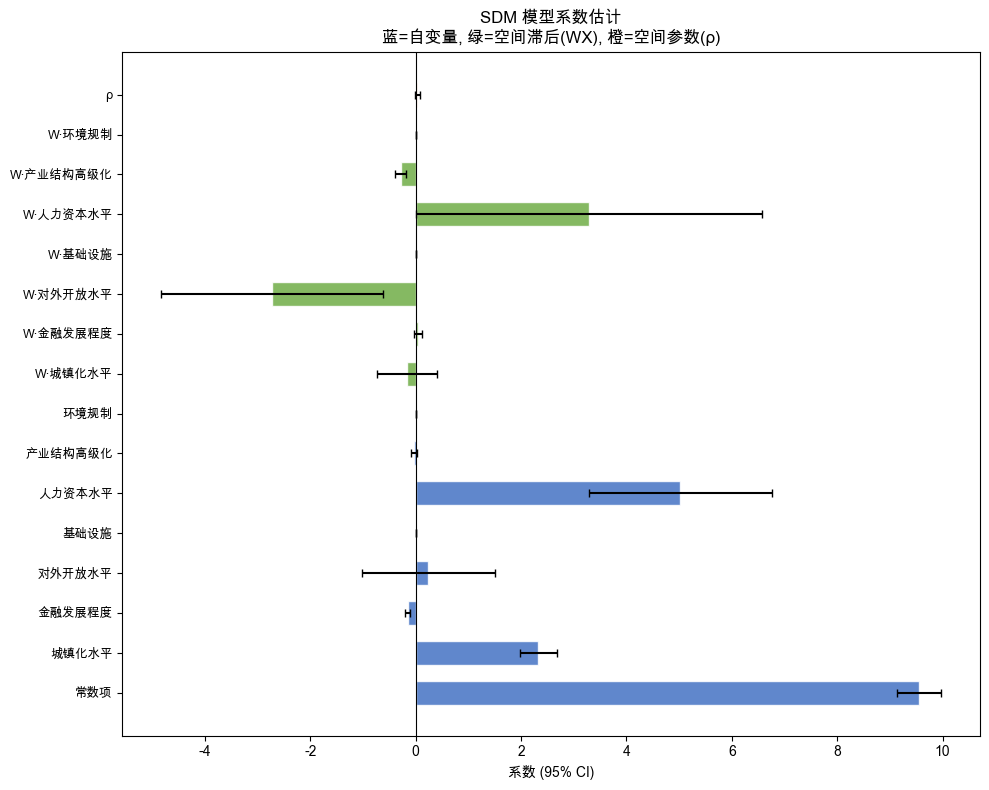

  → output_06_sdm_coefficients.png


In [ ]:
# 第九步：SDM 系数解读（如果 SDM 估计成功）
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("第九步：SDM 系数解读")
print("=" * 60)

if 'SDM' in models:
    sdm_obj = ML_Lag(y, X_const, w=w, slx_lags=1, name_y=Y_VAR, name_x=x_names)
    betas = sdm_obj.betas.flatten()
    z_stats = sdm_obj.z_stat

    print(f"\n  {'变量':<16} {'系数':>10} {'z值':>10} {'p值':>10} {'显著':>6}")
    print(f"  {'─' * 55}")

    # SDM with slx_lags=1: betas 包含 [const, X1..Xk, WX1..WXk, rho]
    n_x = len(X_VARS)
    for i, name in enumerate(x_names):
        coef = betas[i]
        z, p = z_stats[i]
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f"  {name:<16} {coef:>10.4f} {z:>10.4f} {p:>10.4f} {sig:>6}")

    # 空间滞后变量
    print(f"\n  空间滞后解释变量 (WX):")
    for i in range(n_x):
        wx_idx = len(x_names) + i
        if wx_idx < len(betas) - 1:
            coef = betas[wx_idx]
            z, p = z_stats[wx_idx]
            sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
            print(f"  W·{X_VARS[i]:<13} {coef:>10.4f} {z:>10.4f} {p:>10.4f} {sig:>6}")

    rho = betas[-1]
    rho_z, rho_p = z_stats[-1]
    sig = '***' if rho_p < 0.001 else ('**' if rho_p < 0.01 else ('*' if rho_p < 0.05 else ''))
    print(f"\n  ρ (空间滞后)    {rho:>10.6f} {rho_z:>10.4f} {rho_p:>10.6f} {sig:>6}")

    # 系数可视化
    fig, ax = plt.subplots(figsize=(10, 8))
    coef_labels = x_names + [f'W·{v}' for v in X_VARS] + ['ρ']
    coef_vals = list(betas)
    coef_se_vals = []
    for i in range(len(betas)):
        z_i = abs(z_stats[i][0])
        coef_se_vals.append(abs(betas[i] / z_i) if z_i > 0 else 0)

    y_pos = np.arange(len(coef_labels))
    colors_c = ['#4472C4'] * len(x_names) + ['#70AD47'] * len(X_VARS) + ['#ED7D31']
    ax.barh(y_pos, coef_vals, xerr=[1.96 * s for s in coef_se_vals],
            color=colors_c, edgecolor='white', alpha=0.85, height=0.6, capsize=3)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(coef_labels, fontsize=9)
    ax.set_xlabel('系数 (95% CI)')
    ax.set_title('SDM 模型系数估计\n蓝=自变量, 绿=空间滞后(WX), 橙=空间参数(ρ)')
    plt.tight_layout()
    plt.savefig('output_06_sdm_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("  → output_06_sdm_coefficients.png")
else:
    print("  SDM 未成功估计，跳过")

In [ ]:
# 总结
# ---------------------------------------------------------------
print("\n" + "=" * 60)
print("分析总结")
print("=" * 60)
print(f"""
  数据：{ANALYSIS_YEAR}年中国地级市，{n_valid} 个有效样本
  主权重：{primary_name}

  OLS 基准：R² = {models['OLS']['r2']:.4f}
  OLS 残差 Moran's I = {moran_data[0][1]:.4f} (p={moran_data[0][3]:.6f})

  LM 检验推荐：{recommendation}
  最优模型：{best} (AIC = {models[best]['aic']:.2f})
""")
for mn in ['SAR', 'SEM', 'SDM']:
    if mn in models:
        m = models[mn]
        sp = ''
        if 'rho' in m:
            sp += f"ρ={m['rho']:.4f} "
        if 'lam' in m:
            sp += f"λ={m['lam']:.4f} "
        print(f"  {mn}: {sp}伪R²={m['r2']:.4f}, AIC={m['aic']:.2f}")

print(f"\n{'=' * 60}")
print(f"完成！生成 6 张图: output_01~06.png")
print(f"{'=' * 60}")


分析总结

  数据：2021年中国地级市，279 个有效样本
  主权重：Queen

  OLS 基准：R² = 0.6214
  OLS 残差 Moran's I = 0.3830 (p=0.001000)

  LM 检验推荐：SEM
  最优模型：SEM (AIC = 3.83)

  SAR: ρ=0.0329 伪R²=0.6295, AIC=85.59
  SEM: λ=0.6262 伪R²=0.6003, AIC=3.83
  SDM: ρ=0.0309 伪R²=0.6884, AIC=51.30

完成！生成 6 张图: output_01~06.png
